In [5]:
import pandas as pd
import seaborn as sns

In [6]:
# df = pd.read_csv('../dataset.csv', index_col='id')
# df = pd.read_excel('../behaviour_simulation_train.xlsx', index_col='id')

df = pd.read_csv('../behaviour_simulation_train.csv', index_col='id')
df.head()

# drop last row
# df = df.drop(df.index[-1])

,date,likes,content,username,media,inferred company
id,,,,,,
1,2020-12-12 00:47:00,1,"Spend your weekend morning with a Ham, Egg, an...",TimHortonsPH,[Photo(previewUrl='https://pbs.twimg.com/media...,tim hortons
2,2018-06-30 10:04:20,2750,Watch rapper <mention> freestyle for over an H...,IndyMusic,[Photo(previewUrl='https://pbs.twimg.com/media...,independent
3,2020-09-29 19:47:28,57,Canadian Armenian community demands ban on mil...,CBCCanada,[Photo(previewUrl='https://pbs.twimg.com/media...,cbc
4,2020-10-01 11:40:09,152,"1st in Europe to be devastated by COVID-19, It...",MKWilliamsRome,[Photo(previewUrl='https://pbs.twimg.com/media...,williams
5,2018-10-19 14:30:46,41,Congratulations to Pauletha Butts of <mention>...,BGISD,[Photo(previewUrl='https://pbs.twimg.com/media...,independent


<Axes: xlabel='None'>

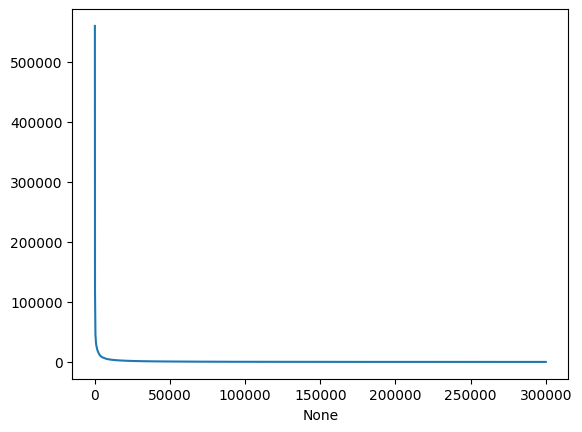

In [7]:
series = pd.Series(df['likes'].values).sort_values(ascending=False).reset_index(drop=True)
sns.lineplot(x=series.index, y=series.values)

In [8]:
df['likes'].quantile(0.9)

np.float64(1295.0)

In [9]:
df['is_viral'] = df['likes'] > 1300

In [10]:
import textblob

textblob_series = df["content"].apply(lambda x: textblob.TextBlob(x))

df["text_subjectivity"] = textblob_series.apply(lambda x: x.sentiment.subjectivity)

df["word_count"] = textblob_series.apply(lambda x: len(x.words))
df["char_count"] = textblob_series.apply(lambda x: len(x.raw))
df["char_density"] = df["char_count"] / df["word_count"]

In [11]:
import nltk

nltk.download("vader_lexicon")
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

polarity_series = df["content"].apply(lambda x: sia.polarity_scores(x))

df["nltk_sentiment_pos"] = polarity_series.apply(lambda x: x["pos"])
df["nltk_sentiment_neu"] = polarity_series.apply(lambda x: x["neu"])
df["nltk_sentiment_neg"] = polarity_series.apply(lambda x: x["neg"])
df["nltk_sentiment"] = polarity_series.apply(lambda x: x["compound"])

[nltk_data] Downloading package vader_lexicon to C:\Users\Neelesh
[nltk_data]     Mishra\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [12]:
df['text_sentiment'] = textblob_series.apply(lambda x: x.sentiment.polarity)

In [13]:
import numpy as np

dt_series = pd.to_datetime(df["date"]).dt

df["post_hour"] = dt_series.hour
df["weekday"] = dt_series.day_of_week

df["post_hour_sin"] = np.sin(df["post_hour"] * (2 * np.pi / 24))
df["post_hour_cos"] = np.cos(df["post_hour"] * (2 * np.pi / 24))

df["weekday_sin"] = np.sin(df["weekday"] * (2 * np.pi / 7))
df["weekday_cos"] = np.cos(df["weekday"] * (2 * np.pi / 7))

In [14]:
df["media_type"] = df["media"].apply(
    lambda x: "Photo" if "Photo" in x else "Gif" if "Gif" in x else "Video"
)

In [15]:
import re

emoji_pattern = re.compile(
    "[\U0001f600-\U0001f64f"  # emoticons
    "\U0001f300-\U0001f5ff"  # symbols & pictographs
    "\U0001f680-\U0001f6ff"  # transport & map
    "\U0001f1e0-\U0001f1ff"  # flags (iOS)
    "\U00002700-\U000027bf"  # dingbats
    "\U000024c2-\U0001f251"  # enclosed characters
    "]+",
    flags=re.UNICODE,
)


df["has_mention"] = df["content"].str.contains("<mention>").astype(int)
df["has_emoji"] = (
    df["content"].apply(lambda x: bool(emoji_pattern.search(x))).astype(int)
)

In [16]:
from sklearn.preprocessing import LabelEncoder

le_company = LabelEncoder()
df["company_enc"] = le_company.fit_transform(df["inferred company"])

le_username = LabelEncoder()
df["username_enc"] = le_username.fit_transform(df["username"])

In [17]:
df["num_emojis"] = df["content"].apply(lambda x: len(emoji_pattern.findall(x)))
df["num_mentions"] = df["content"].apply(lambda x: x.count("<mention>"))
df["num_hyperlinks"] = df["content"].apply(lambda x: x.count("<hyperlink>"))
df["num_hashtags"] = df["content"].apply(lambda x: x.count("#"))

df["has_hashtags"] = df["num_hashtags"].apply(lambda x: 1 if x > 0 else 0)

In [18]:
df["emoji_density"] = df["num_emojis"] / df["word_count"]

In [19]:
df["is_morning_post"] = df["post_hour"].apply(lambda x: 1 if 5 <= x < 12 else 0)
df["is_afternoon_post"] = df["post_hour"].apply(lambda x: 1 if 12 <= x < 17 else 0)
df["is_evening_post"] = df["post_hour"].apply(lambda x: 1 if 17 <= x < 21 else 0)
df["is_night_post"] = df["post_hour"].apply(lambda x: 1 if 21 <= x < 5 else 0)

In [20]:
df["is_weekend_post"] = df["weekday"].apply(lambda x: 1 if x >= 5 else 0)

In [21]:
df["log_likes"] = np.log1p(df["likes"])

In [22]:
# for all columns that start with 'has_word_'
has_word_cols = [col for col in df.columns if col.startswith("has_word_")]
# print number of tweets that contain each word
for col in has_word_cols:
    print(f"{col}: {df[col].sum()} tweets contain this word")

In [23]:
from sklearn.model_selection import train_test_split

feature_cols = [
    "nltk_sentiment",
    "text_subjectivity",
    "word_count",
    "char_density",
    "post_hour",
    "weekday",
    "media_type_Photo",
    "media_type_Video",
    # "has_mention",
    # "has_emoji",
    # "num_emojis",
    # "has_hashtags",
    # "num_hashtags",
    "company_enc",
    "username_enc",
]


X = pd.get_dummies(
    df,
    columns=["media_type"],
    drop_first=True
)[feature_cols]
y = df["log_likes"]

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# add target encoding of username and inferred company
# X_train["username_enc"] = df.loc[X_train.index, "username_enc"]

<Axes: xlabel='text_sentiment', ylabel='nltk_sentiment'>

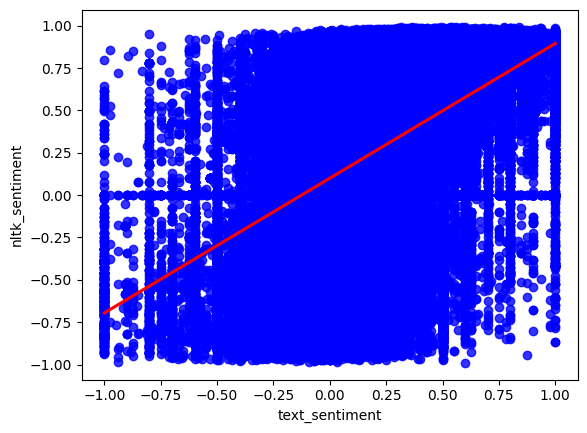

In [24]:
sns.regplot(
    data=df,
    x="text_sentiment",
    y="nltk_sentiment",
    # hue='is_viral',
    scatter_kws={"color": "blue"},  # color of the points
    line_kws={"color": "red"},
)

In [25]:
# use xgboost for regression
import xgboost as xgb
# Initialize the XGBRegressor
xgb_regressor = xgb.XGBRegressor(
    n_estimators=200, random_state=42, objective='reg:squarederror'
)
# Fit the model
xgb_regressor.fit(X_train, y_train)
# Get feature importances
feature_importances_xgb = xgb_regressor.feature_importances_
# Create a DataFrame for feature importances
feature_importance_df_xgb = pd.DataFrame(
    {"Feature": X.columns, "Importance": feature_importances_xgb}
).sort_values(by="Importance", ascending=False)
# Display the feature importances
print(feature_importance_df_xgb)

             Feature  Importance
9       username_enc    0.347788
8        company_enc    0.313815
7   media_type_Video    0.236329
6   media_type_Photo    0.032432
2         word_count    0.028043
3       char_density    0.017962
4          post_hour    0.009134
5            weekday    0.006760
0     nltk_sentiment    0.004063
1  text_subjectivity    0.003675


In [26]:
# df.to_csv('processed.csv', index=True)

In [27]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(stop_words="english", max_features=1000, ngram_range=(1, 2))
# X_tfidf = tfidf.fit_transform(df['content'])
# feature_names = tfidf.get_feature_names_out()

In [28]:
# get predictions
y_pred_xgb = xgb_regressor.predict(X_test)
# print rmse
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(np.expm1(y_test), np.expm1(y_pred_xgb))
print(f"RMSE: {rmse}")
print(root_mean_squared_error(y_test, y_pred_xgb))


RMSE: 4477.291657235145
0.9199514474682415


In [29]:
df['likes'].describe()

count    300000.000000
mean        773.364793
std        4931.463419
min           0.000000
25%           3.000000
50%          76.000000
75%         364.000000
max      560193.000000
Name: likes, dtype: float64

In [ ]:
df.to_csv('processed.csv', index=True)

: 